   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 6.8 MB/s eta 0:00:00


/tmp/ipykernel_2339/2747859378.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + [benchmark], start=start, end=end)['Close']
[*********************100%***********************]  16 of 16 completed


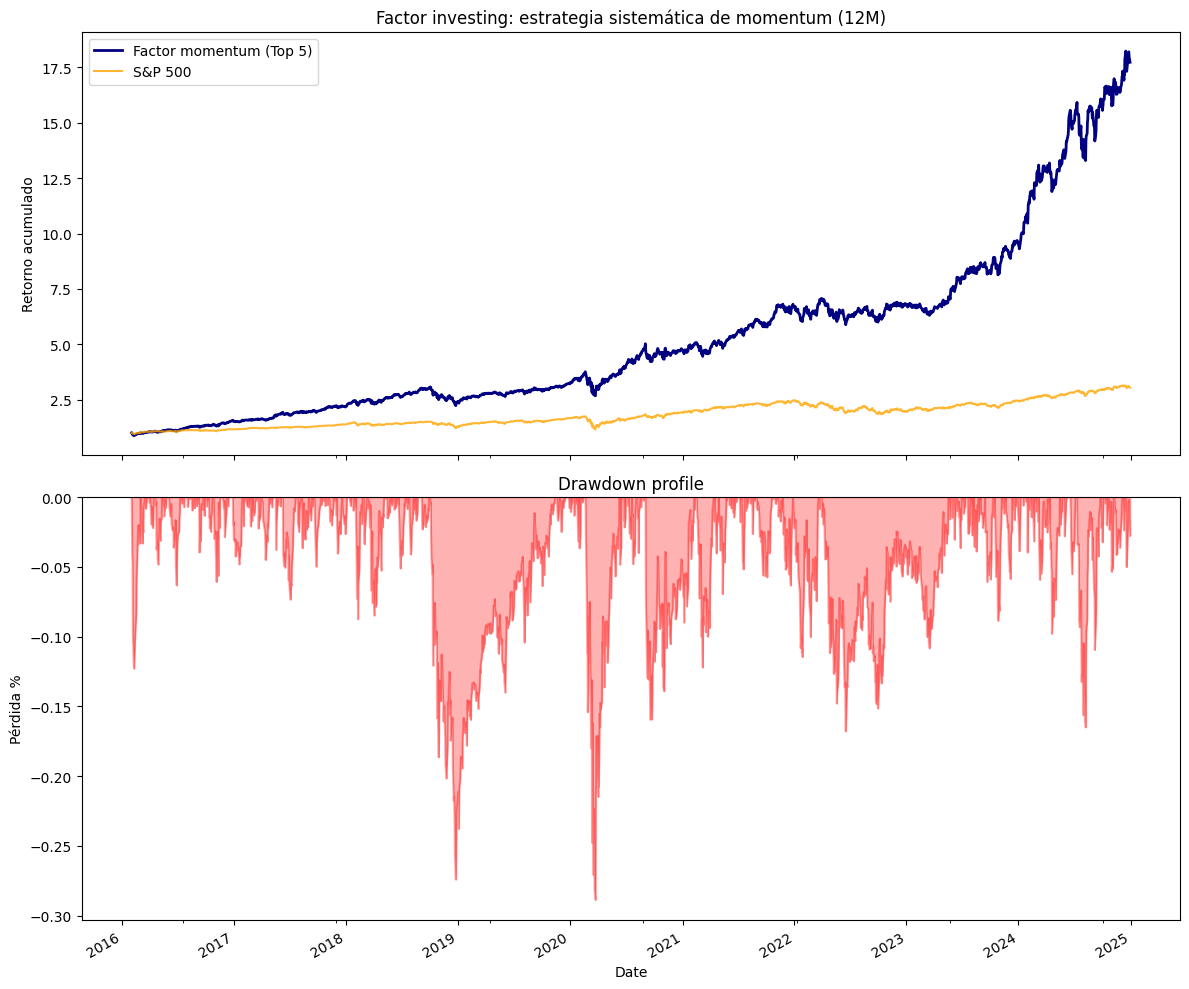


Métrica              | Momentum Strat  | S&P 500
-------------------------------------------------------
CAGR (Anual)         |         38.12% | 13.32%
Volatilidad          |         24.62% | 18.01%
Ratio Sharpe         |           1.43 | 0.57
Ratio Sortino        |           1.90 | 0.68
Max Drawdown         |        -28.87% | -33.92%
Ratio Calmar         |           1.32 | 0.39


In [1]:
#PROYECTO: Systematic_Trading_Strategies
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Replicar el factor Momentum de Carhart con rebalanceo mensual

!pip install -q yfinance PyPortfolioOpt cvxpy statsmodels pandas_datareader scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#1. DESCARGA (universo de acciones Large-Cap)
tickers = [
    "AAPL","MSFT","NVDA","AMZN","GOOGL",
    "META","JPM","XOM","UNH","HD",
    "PG","MA","LLY","AVGO","COST"
]
benchmark = "^GSPC"
start = "2015-01-01"
end = "2024-12-31"

data = yf.download(tickers + [benchmark], start=start, end=end)['Close']

prices = data[tickers].dropna()
sp500 = data[benchmark].dropna()
daily_returns = prices.pct_change().dropna()

#2. CÁLCULO DEL FACTOR MOMENTUM (12 Meses)
#Retorno acumulado de los últimos 252 días de trading (aprox 1 año)
momentum_12m = prices.pct_change(252)

#3. MOTOR DE REBALANCEO MENSUAL (Walk-Forward)

#Agrupamos por año y mes para extraer el último día de trading
last_trading_days = prices.groupby([prices.index.year, prices.index.month]).apply(lambda x: x.index[-1]).values
rebalance_dates = pd.DatetimeIndex(last_trading_days)

portfolio_returns = []

for i in range(12, len(rebalance_dates)-1):
    date = rebalance_dates[i]
    next_date = rebalance_dates[i+1]

    #1. Factor Ranking: Extraemos el momentum score en el día de rebalanceo exacto
    mom_scores = momentum_12m.loc[date]

    #2. Stock Selection: Seleccionamos el top 5 (Winners)
    winners = mom_scores.nlargest(5).index

    #3. Portfolio Construction: Retornos diarios del mes siguiente (Out-of-sample)
    mask = (daily_returns.index > date) & (daily_returns.index <= next_date)
    month_returns = daily_returns.loc[mask, winners]

    #4. Asignación Equal Weight (20% a cada una de las 5 acciones)
    daily_port_ret = month_returns.mean(axis=1)
    portfolio_returns.append(daily_port_ret)

#Unimos la historia de la estrategia
strategy_returns = pd.concat(portfolio_returns)
sp_returns = sp500.pct_change().loc[strategy_returns.index]

#4. MÉTRICAS DE PERFORMANCE INSTITUCIONAL
def get_performance(ret_series):
    cum_ret = (1 + ret_series).cumprod()
    total_ret = cum_ret.iloc[-1] - 1

    #CAGR
    years = len(ret_series) / 252  # 252 días por año en datos diarios
    cagr = (1 + total_ret)**(1/years) - 1

    #Riesgo
    vol = ret_series.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol
    downside_vol = ret_series[ret_series < 0].std() * np.sqrt(252)
    sortino = (cagr - 0.03) / downside_vol

    #Drawdown y Calmar
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd)

    return cagr, vol, sharpe, sortino, max_dd, calmar

strat_m = get_performance(strategy_returns)
bench_m = get_performance(sp_returns)

#5. VISUALIZACIÓN DEL BACKTEST
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#Equity Curve
((1 + strategy_returns).cumprod()).plot(ax=ax1, label='Factor momentum (Top 5)', color='navy', lw=2)
((1 + sp_returns).cumprod()).plot(ax=ax1, label='S&P 500', color='orange', alpha=0.8)
ax1.set_title('Factor investing: estrategia sistemática de momentum (12M)')
ax1.set_ylabel('Retorno acumulado')
ax1.legend()

#Drawdown
cum_strat = (1 + strategy_returns).cumprod()
dd_strat = (cum_strat - cum_strat.cummax()) / cum_strat.cummax()
dd_strat.plot.area(ax=ax2, color='red', alpha=0.3)
ax2.set_title('Drawdown profile')
ax2.set_ylabel('Pérdida %')

plt.tight_layout()
plt.show()

#Reporte
print(f"\n{'Métrica':<20} | {'Momentum Strat':<15} | {'S&P 500'}")
print("-" * 55)
print(f"{'CAGR (Anual)':<20} | {strat_m[0]:>14.2%} | {bench_m[0]:.2%}")
print(f"{'Volatilidad':<20} | {strat_m[1]:>14.2%} | {bench_m[1]:.2%}")
print(f"{'Ratio Sharpe':<20} | {strat_m[2]:>14.2f} | {bench_m[2]:.2f}")
print(f"{'Ratio Sortino':<20} | {strat_m[3]:>14.2f} | {bench_m[3]:.2f}")
print(f"{'Max Drawdown':<20} | {strat_m[4]:>14.2%} | {bench_m[4]:.2%}")
print(f"{'Ratio Calmar':<20} | {strat_m[5]:>14.2f} | {bench_m[5]:.2f}")